In [1]:
import numpy as np

X1_train = np.load("../models/X1_train.npy")
X1_test  = np.load("../models/X1_test.npy")
y1_train = np.load("../models/y1_train.npy")
y1_test  = np.load("../models/y1_test.npy")

print("Train shape:", X1_train.shape, y1_train.shape)
print("Test shape:", X1_test.shape, y1_test.shape)


Train shape: (59793, 48, 10) (59793, 6, 4)
Test shape: (14949, 48, 10) (14949, 6, 4)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Attention, Concatenate, Reshape

timesteps = X1_train.shape[1]
features = X1_train.shape[2]

inputs = Input(shape=(timesteps, features))

# First LSTM layer
x = LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.3)(x)

# GRU layer to capture different temporal patterns
x = GRU(64, return_sequences=True)(x)
x = Dropout(0.3)(x)

# Attention mechanism
attention = Attention()([x, x])
x = Concatenate()([x, attention])

# Final LSTM layer
x = LSTM(64)(x)
x = Dropout(0.3)(x)

# Output layer
output = Dense(6 * 4)(x)
output = Reshape((6, 4))(output)

model1 = Model(inputs, output)

model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model1.summary()

#Baseline LSTM model (commented out for now) similar performance to the improved model, so we can focus on the new architecture

# model1 = Sequential([
#     LSTM(64, return_sequences=True, input_shape=(X1_train.shape[1], X1_train.shape[2])),
#     Dropout(0.2),
    
#     LSTM(32),
#     Dropout(0.2),
    
#     Dense(6 * 4),  # 6 future steps × 4 parameters
# ])

# # Reshape output to (forecast_horizon, features)
# model1.add(tf.keras.layers.Reshape((6, 4)))

# model1.compile(
#     optimizer='adam',
#     loss='mse',
#     metrics=['mae']
# )

# model1.summary()



In [4]:
# base model training with early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model1.fit(
    X1_train, y1_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

# training for improved model with early stopping

# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=7,
#     restore_best_weights=True
# )

# history = model1.fit(
#     X1_train, y1_train,
#     validation_split=0.2,
#     epochs=60,
#     batch_size=128,
#     callbacks=[early_stop]
# )


Epoch 1/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 0.0196 - mae: 0.1059 - val_loss: 0.0145 - val_mae: 0.0958
Epoch 2/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - loss: 0.0123 - mae: 0.0849 - val_loss: 0.0142 - val_mae: 0.0949
Epoch 3/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - loss: 0.0112 - mae: 0.0802 - val_loss: 0.0141 - val_mae: 0.0948
Epoch 4/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 77s 103ms/step - loss: 0.0107 - mae: 0.0773 - val_loss: 0.0140 - val_mae: 0.0945
Epoch 5/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - loss: 0.0103 - mae: 0.0753 - val_loss: 0.0139 - val_mae: 0.0939
Epoch 6/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - loss: 0.0099 - mae: 0.0738 - val_loss: 0.0135 - val_mae: 0.0926
Epoch 7/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - loss: 0.0096 - mae: 0.0724 - val_loss: 0.0129 - val_mae: 0.0907
Epoch 8/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - loss: 0.0094 - mae: 0.0713 - val_loss: 0.0126 - val_mae: 0.0896
Epoch 9/50
748/748 ━━━━━━━━━━━━━━━━

In [5]:
import json

with open("../models/feature_columns.json", "r") as f:
    feature_columns = json.load(f)

print(feature_columns)

target_indices = [
    feature_columns.index("do"),
    feature_columns.index("temperature"),
    feature_columns.index("ph"),
    feature_columns.index("turbidity")
]



['nitrate', 'ph', 'ammonia', 'temperature', 'do', 'turbidity', 'hour_sin', 'hour_cos', 'ammonia_ph', 'ammonia_temp']


In [6]:
test_loss, test_mae = model1.evaluate(X1_test, y1_test)
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
y1_pred = model1.predict(X1_test)
print("Predicted shape:", y1_pred.shape)

468/468 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0124 - mae: 0.0884
Test Loss (MSE): 0.012444302439689636
Test MAE: 0.08842001855373383
468/468 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
Predicted shape: (14949, 6, 4)


In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("y_test shape :", y1_test.shape)
print("y_pred shape :", y1_pred.shape)

# ================================
# 1️⃣ OVERALL METRICS (Flattened)
# ================================

y_true_all = y1_test.reshape(-1)
y_pred_all = y1_pred.reshape(-1)

mse = mean_squared_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_all, y_pred_all)
r2 = r2_score(y_true_all, y_pred_all)

mape = np.mean(
    np.abs((y_true_all - y_pred_all) / np.clip(y_true_all, 1e-8, None))
) * 100

smape = 100 * np.mean(
    2 * np.abs(y_pred_all - y_true_all) /
    (np.abs(y_true_all) + np.abs(y_pred_all) + 1e-8)
)

rae = np.sum(np.abs(y_true_all - y_pred_all)) / \
      np.sum(np.abs(y_true_all - np.mean(y_true_all)))

# ---- MASE (naive lag-1 baseline) ----
naive_forecast = y_true_all[:-1]
actual = y_true_all[1:]
mae_naive = np.mean(np.abs(actual - naive_forecast))
mase = mae / mae_naive

print("\n================ OVERALL METRICS ================")
print(f"MAE   : {mae:.6f}")
print(f"MSE   : {mse:.6f}")
print(f"RMSE  : {rmse:.6f}")
print(f"MAPE  : {mape:.6f}")
print(f"SMAPE : {smape:.6f}")
print(f"R2    : {r2:.6f}")
print(f"RAE   : {rae:.6f}")
print(f"MASE  : {mase:.6f}")

y_test shape : (14949, 6, 4)
y_pred shape : (14949, 6, 4)

================ OVERALL METRICS ================
MAE   : 0.088420
MSE   : 0.012444
RMSE  : 0.111554
MAPE  : 20.256748
SMAPE : 18.335018
R2    : 0.527710
RAE   : 0.653755
MASE  : 0.467013


In [8]:
sample_index = 0

pred = y1_pred[sample_index]
true = y1_test[sample_index]

print("Predicted (scaled):")
print(pred)

print("\nActual (scaled):")
print(true)

Predicted (scaled):
[[0.6727546  0.65626466 0.4082088  0.41470608]
 [0.6367855  0.64883894 0.4222241  0.33728516]
 [0.5705702  0.6543825  0.5135221  0.35439336]
 [0.57422924 0.65034974 0.5090751  0.35531312]
 [0.5707585  0.6498546  0.5041541  0.3528995 ]
 [0.5699954  0.6512336  0.51121163 0.3481981 ]]

Actual (scaled):
[[0.7596841  0.7030635  0.4495016  0.43035117]
 [0.7837728  0.59835345 0.57125384 0.29907888]
 [0.75830394 0.6587074  0.55823386 0.3695383 ]
 [0.690758   0.64540994 0.6169695  0.4497669 ]
 [0.5979764  0.65115184 0.5295531  0.49557662]
 [0.5331886  0.5724362  0.5103446  0.42267594]]


In [9]:
model1.save("../models/model1_multivariate_lstm.keras")

In [10]:
import numpy as np

params = ["DO", "Temperature", "pH", "Turbidity"]

mae_per_param = np.mean(np.abs(y1_test - y1_pred), axis=(0,1))

for p, v in zip(params, mae_per_param):
    print(p, "MAE:", v)


DO MAE: 0.096457124
Temperature MAE: 0.07089295
pH MAE: 0.109784596
Turbidity MAE: 0.07654472


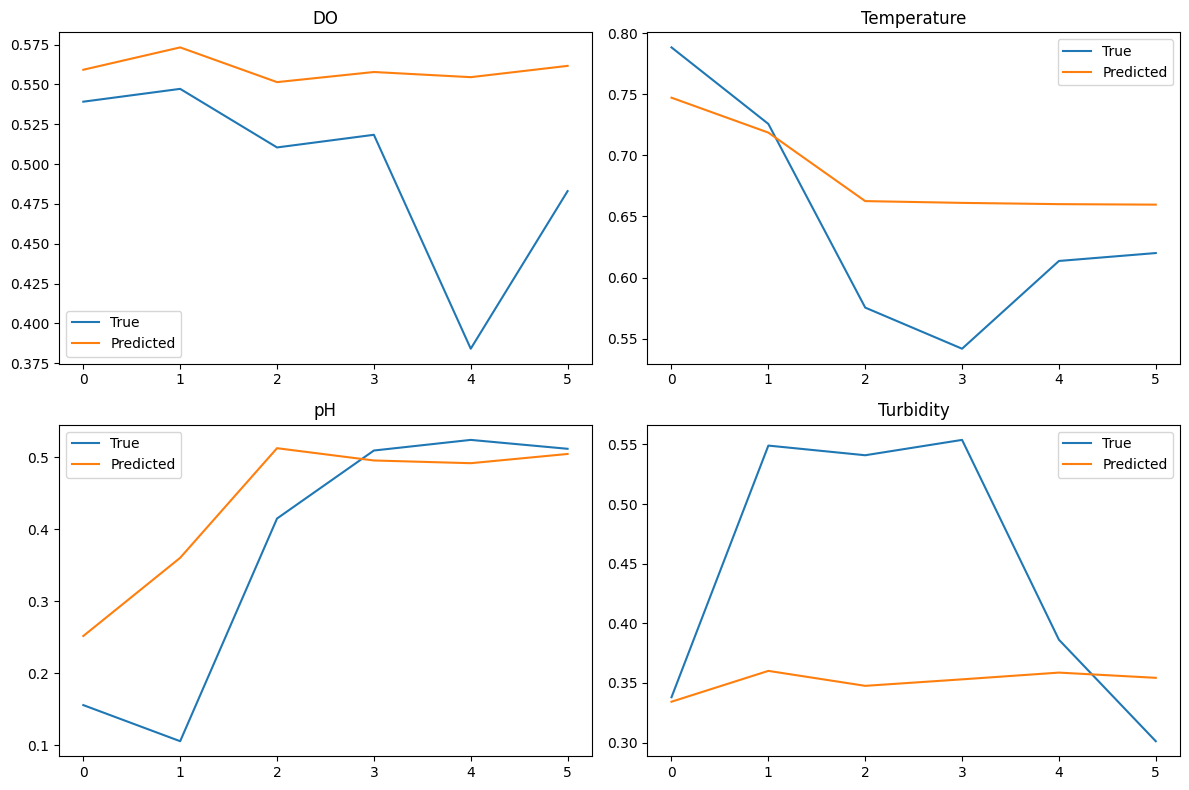

In [11]:
import matplotlib.pyplot as plt
model1 = tf.keras.models.load_model("../models/model1_multivariate_lstm.keras")

# Pick one test sample
sample = 10  

true_values = y1_test[sample]
pred_values = y1_pred[sample]

params = ["DO", "Temperature", "pH", "Turbidity"]

plt.figure(figsize=(12, 8))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(true_values[:, i], label="True")
    plt.plot(pred_values[:, i], label="Predicted")
    plt.title(params[i])
    plt.legend()

plt.tight_layout()
plt.show()


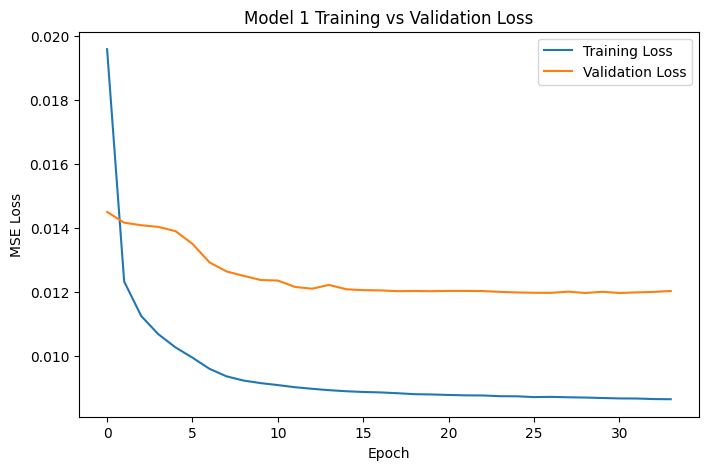

In [12]:
# Training and Validation Loss Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model 1 Training vs Validation Loss')
plt.legend()
plt.show()


468/468 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0124 - mae: 0.0884


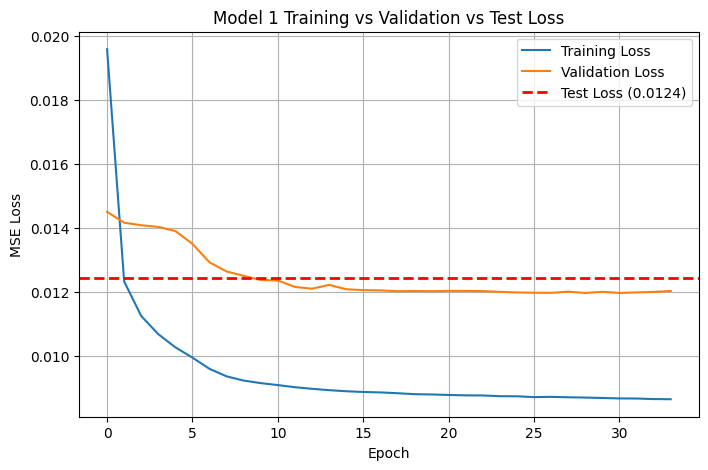

In [13]:
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_mae = model1.evaluate(X1_test, y1_test)

plt.figure(figsize=(8,5))

# Training & Validation curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# ✅ Test loss as horizontal line
plt.axhline(
    y=test_loss,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Test Loss ({test_loss:.4f})'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model 1 Training vs Validation vs Test Loss')
plt.legend()
plt.grid(True)

plt.show()

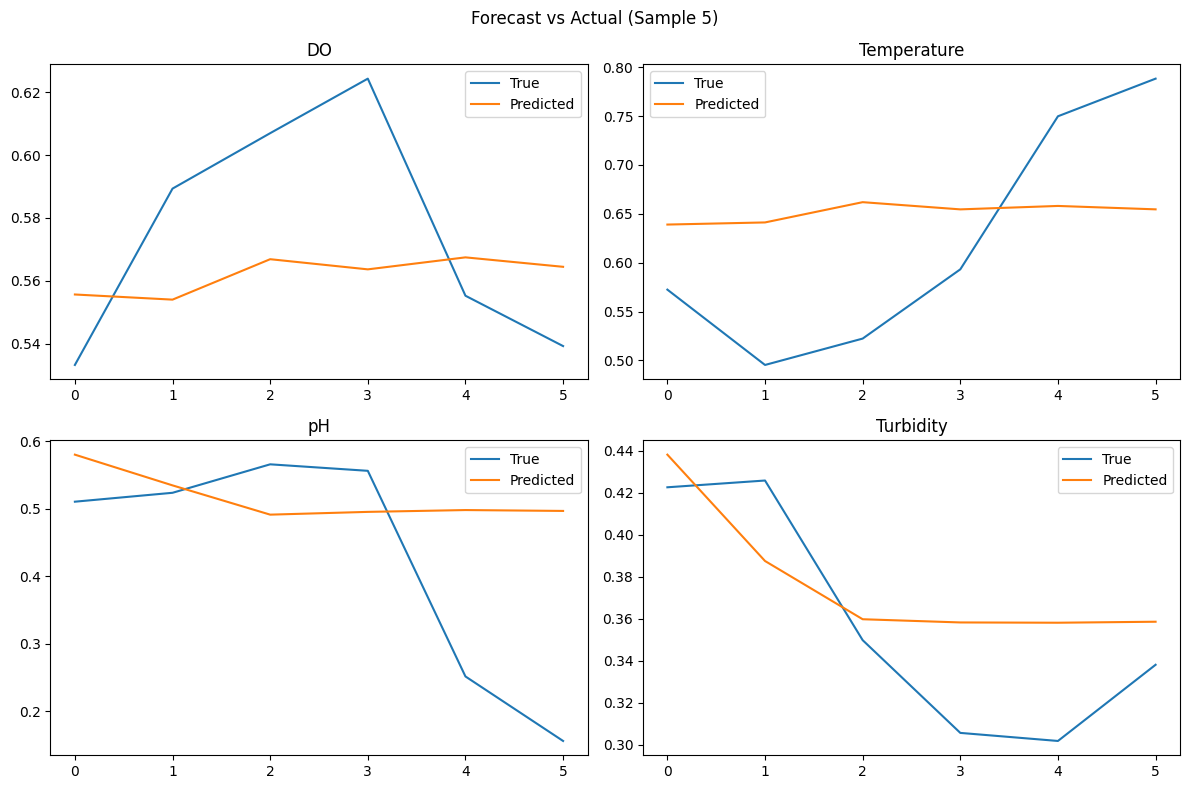

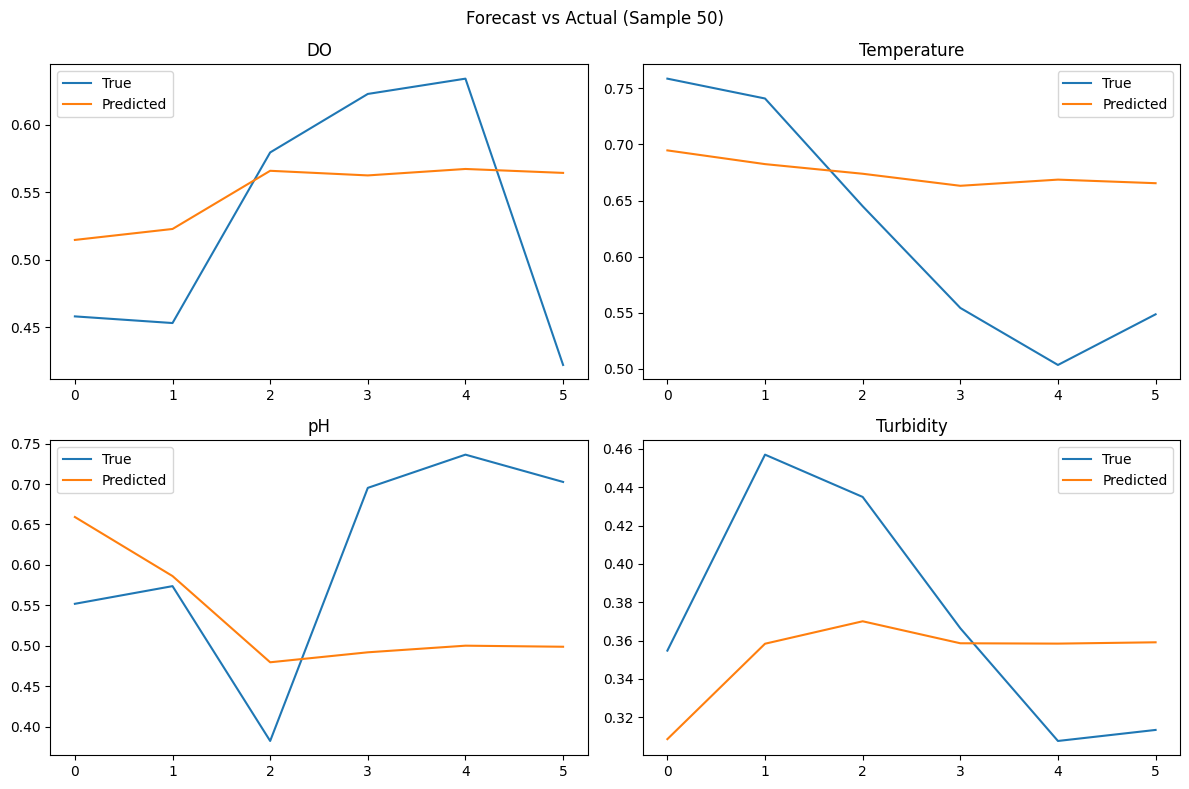

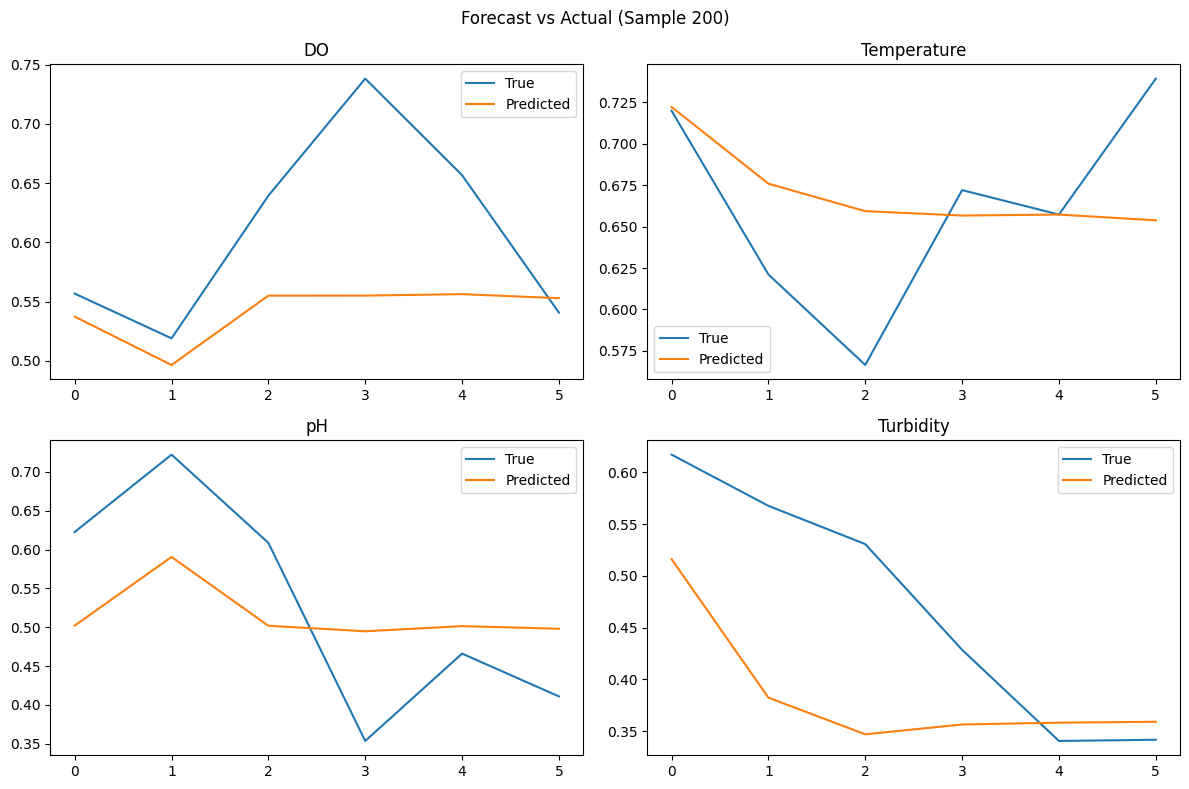

In [13]:
# Multi-Step Forecast Plot
params = ["DO", "Temperature", "pH", "Turbidity"]

samples_to_plot = [5, 50, 200]

for sample in samples_to_plot:
    plt.figure(figsize=(12,8))
    true_values = y1_test[sample]
    pred_values = y1_pred[sample]

    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.plot(true_values[:,i], label='True')
        plt.plot(pred_values[:,i], label='Predicted')
        plt.title(params[i])
        plt.legend()

    plt.suptitle(f"Forecast vs Actual (Sample {sample})")
    plt.tight_layout()
    plt.show()


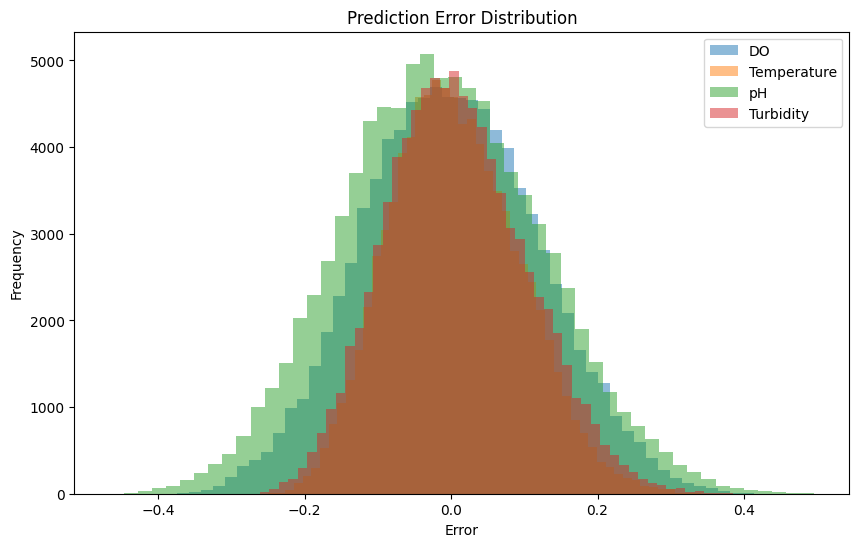

In [14]:
# Error Distribution Histogram
import numpy as np

errors = y1_test - y1_pred
errors_flat = errors.reshape(-1, errors.shape[-1])

plt.figure(figsize=(10,6))
for i, param in enumerate(params):
    plt.hist(errors_flat[:, i], bins=50, alpha=0.5, label=param)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


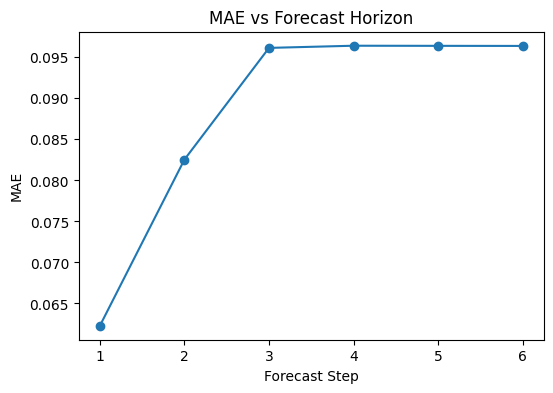

In [15]:
# MAE per Forecast Horizon Step
mae_per_step = np.mean(np.abs(y1_test - y1_pred), axis=(0,2))

plt.figure(figsize=(6,4))
plt.plot(range(1,7), mae_per_step, marker='o')
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Forecast Step")
plt.ylabel("MAE")
plt.show()


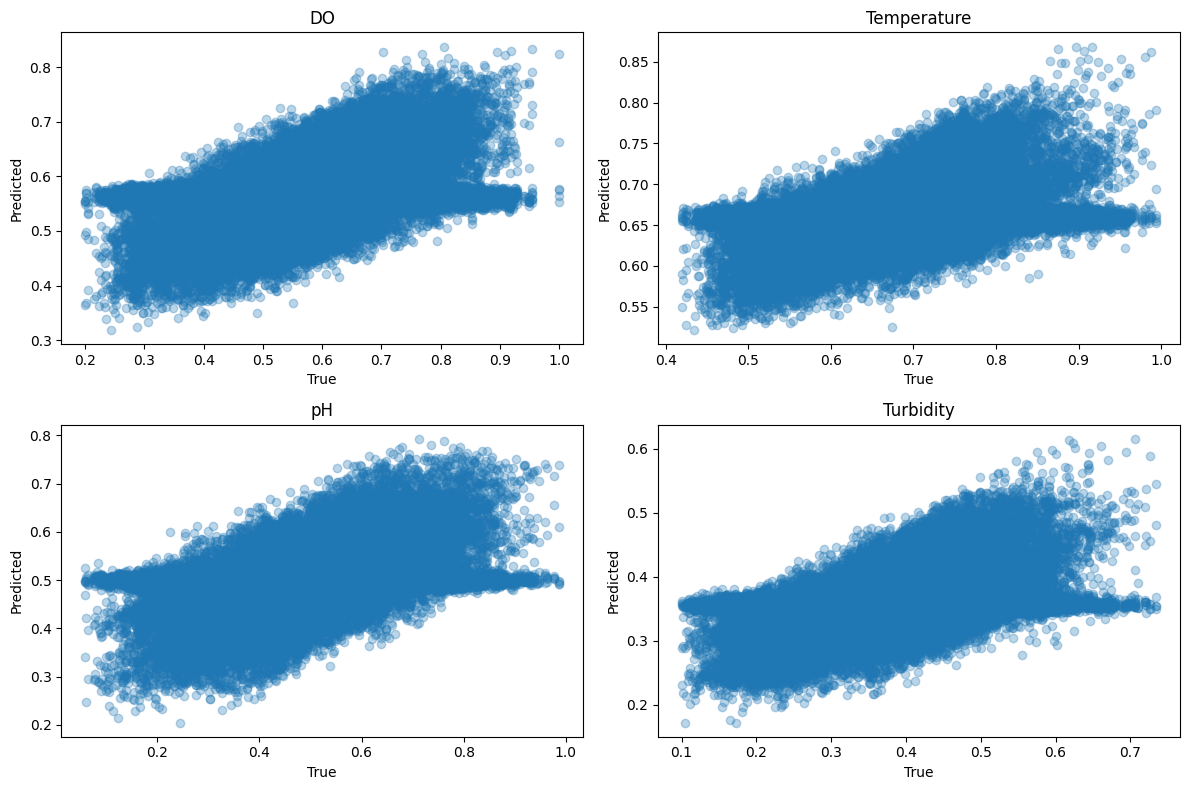

In [16]:
# Predicted vs True Scatter Plot
plt.figure(figsize=(12,8))

for i, param in enumerate(params):
    plt.subplot(2,2,i+1)
    plt.scatter(y1_test[:,:,i].flatten(), y1_pred[:,:,i].flatten(), alpha=0.3)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(param)

plt.tight_layout()
plt.show()


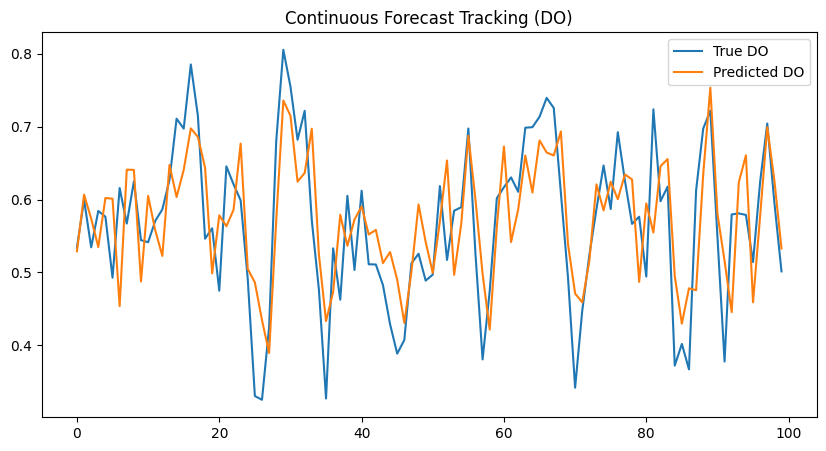

In [17]:
# Time-Series Overlay (Long Continuous Segment)
start = 1000
length = 100

true_segment = y1_test[start:start+length, 0, 0]   # DO at first future step
pred_segment = y1_pred[start:start+length, 0, 0]

plt.figure(figsize=(10,5))
plt.plot(true_segment, label="True DO")
plt.plot(pred_segment, label="Predicted DO")
plt.title("Continuous Forecast Tracking (DO)")
plt.legend()
plt.show()
